# Task 5 — A real time series (Airline passengers)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "legend.frameon": False, "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def finish(fig, title, subtitle=None, note=None, name=None):
    fig.tight_layout()
    tr = lambda y: offset_copy(fig.transFigure, fig=fig, y=y, units="points")
    if subtitle:
        fig.text(0.01, 1, subtitle, va="bottom", fontsize=10, color=INK_SOFT, transform=tr(4))
    fig.text(0.01, 1, title, va="bottom", fontsize=14, fontweight="bold", color=INK,
             transform=tr(22 if subtitle else 6))
    if note:
        fig.text(0.01, 0, note, va="top", fontsize=9, color=INK_MUTED, transform=tr(-4))
    if name:
        fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)
    plt.show()

In [2]:
fl = pd.read_csv(DATA / "flights.csv")
print(fl.shape, "missing:", fl.isna().sum().sum())
fl.head()

(144, 3) missing: 0


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


## 1. Passengers over time

`month` is text ("January", ...) so it would sort alphabetically. I turn it into a month number and build a
real date from year + month, then sort by it.

In [3]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]
fl["month_num"] = fl["month"].map({m: i + 1 for i, m in enumerate(MONTHS)})
fl["date"] = pd.to_datetime(dict(year=fl["year"], month=fl["month_num"], day=1))
fl = fl.sort_values("date").reset_index(drop=True)
fl[["date", "passengers"]].head(14)

,date,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


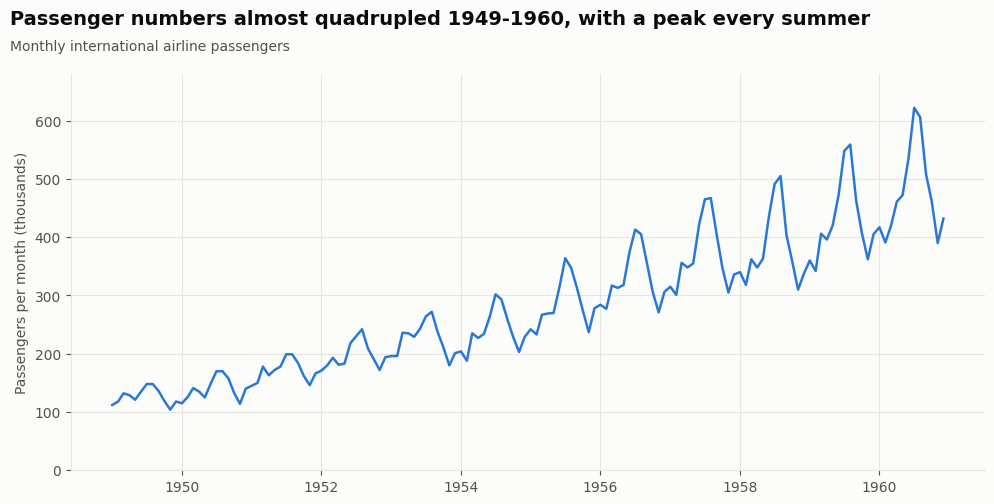

In [4]:
yearly = fl.groupby("year")["passengers"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(fl["date"], fl["passengers"], color=BLUE, linewidth=1.8)
ax.set_ylim(0, 680)
ax.set_ylabel("Passengers per month (thousands)")

finish(fig, f"Passenger numbers almost quadrupled 1949-1960, with a peak every summer",
       "Monthly international airline passengers",
       name="task5_timeseries")

**Chart analysis.** Passenger numbers grow roughly fourfold while a regular yearly wave rides on top of the trend. This is the only chart that carries both halves of the story at once.

**Why:** one value over time → single line chart. Y-axis starts at 0 so the growth isn't exaggerated.
(Units: the classic Box & Jenkins airline data is in thousands of passengers.)

## 2. The seasonal cycle on its own

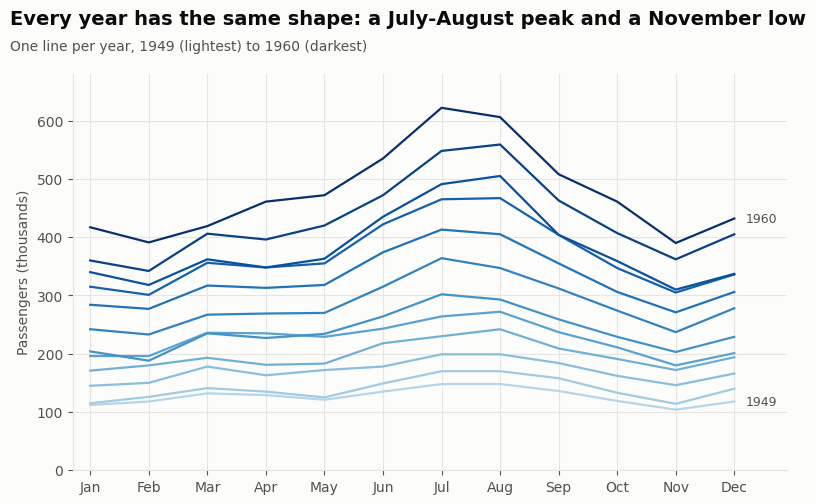

In [5]:
wide = fl.pivot(index="month_num", columns="year", values="passengers")
cmap = plt.get_cmap("Blues")
years = wide.columns

fig, ax = plt.subplots()
for i, y in enumerate(years):
    ax.plot(wide.index, wide[y], color=cmap(0.3 + 0.7 * i / (len(years) - 1)), linewidth=1.6)
for y in [years[0], years[-1]]:
    ax.text(12.2, wide[y].iloc[-1], str(y), va="center", color=INK_SOFT, fontsize=9)
ax.set_xticks(range(1, 13), [m[:3] for m in MONTHS])
ax.set_xlim(0.7, 12.9)
ax.set_ylim(0, 680)
ax.set_ylabel("Passengers (thousands)")

finish(fig, "Every year has the same shape: a July-August peak and a November low",
       "One line per year, 1949 (lightest) to 1960 (darkest)", name="task5_seasonal")

**Chart analysis.** Putting months on the x-axis removes the long-term trend from that direction, leaving only the within-year shape: a pronounced summer peak that sharpens slightly in the later, darker years.

**Why:** months on the x-axis and one line per year takes the long-term trend out of the x direction, so
only the within-year pattern is left. Colour goes light → dark with the year, so it means something (older
vs newer) and I didn't need a 12-item legend, just labelled the first and last year.

## 3. Which month is busiest?

In [6]:
fl["share"] = fl["passengers"] / fl.groupby("year")["passengers"].transform("sum") * 100
share = fl.groupby("month_num")["share"].mean()

rank = wide.rank(ascending=False)
print("July/August are the top 2 every year:", ((rank.loc[[7, 8]] <= 2).all()).all())
print("August busier:", (wide.loc[8] > wide.loc[7]).sum(), " July busier:", (wide.loc[7] > wide.loc[8]).sum(),
      " tied:", (wide.loc[7] == wide.loc[8]).sum())
wide.loc[[7, 8]]

July/August are the top 2 every year: True
August busier: 5  July busier: 4  tied: 3


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month_num,,,,,,,,,,,,
7,148,170,199,230,264,302,364,413,465,491,548,622
8,148,170,199,242,272,293,347,405,467,505,559,606


July and August are always the top two, and they swap places: August is busier in 5 years, July in 4,
and in 1949–51 they're exactly tied. So the honest answer is "July and August together", not one month.
To compare months fairly across years with very different totals I use each month's **share of that
year's passengers**.

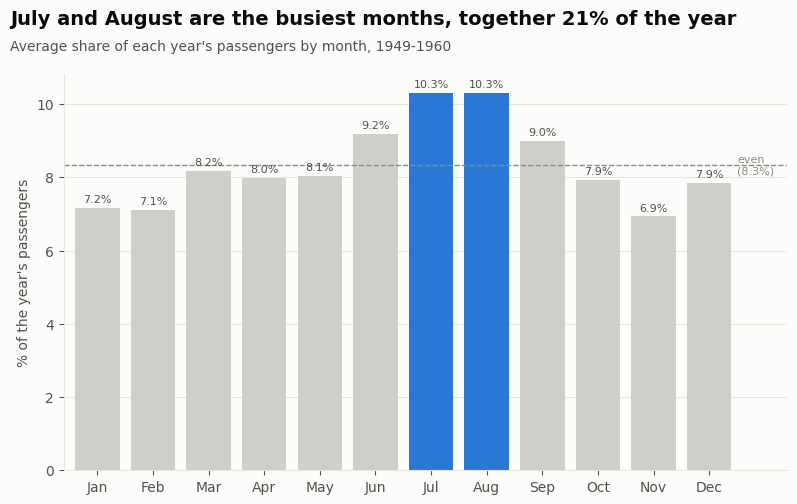

In [7]:
fig, ax = plt.subplots()
colors = [BLUE if m in (7, 8) else QUIET for m in share.index]
bars = ax.bar(share.index, share.values, color=colors)
for bar, v in zip(bars, share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.15, f"{v:.1f}%", ha="center", fontsize=8, color=INK_SOFT)
ax.axhline(100 / 12, color=INK_MUTED, linestyle="--", linewidth=1)
ax.set_xlim(0.4, 13.4)
ax.text(12.5, 100 / 12, "even\n(8.3%)", color=INK_MUTED, fontsize=8, va="center")
ax.set_xticks(range(1, 13), [m[:3] for m in MONTHS])
ax.set_ylabel("% of the year's passengers")
ax.grid(axis="x", visible=False)

finish(fig, f"July and August are the busiest months, together {share[[7, 8]].sum():.0f}% of the year",
       "Average share of each year's passengers by month, 1949-1960", name="task5_busiest_month")

**Chart analysis.** Measured as a share of each year's total, July and August sit clearly above the even-year reference line. The two swap first place between years, so the honest answer is both months together.

**Why:** comparing one value across 12 categories → bar chart, starting at 0. Blue only for the answer
(Jul/Aug), everything else grey. The dashed line shows what an even year would look like.

## 4. Which chart goes in the report?

I would put the **first chart** (the full time series) in the report. It's the only one that shows
both the growth and the seasonality, which is the main story of this data.

The other two answer narrower follow-up questions. The seasonal chart repeats the pattern already visible
in chart 1, and the busiest-month chart throws away the growth completely. Putting all three next to each
other would mean the reader sees the same seasonality three times. They'd make sense as an appendix, or if
the report was specifically about scheduling for peak months (then chart 3 would be the main one).

## Is the seasonality growing, or just the airline?

In [8]:
amp = pd.DataFrame({
    "mean": wide.mean(),
    "peak - low": wide.max() - wide.min(),
    "peak / low": wide.max() / wide.min(),
})
amp.round(2)

,mean,peak - low,peak / low
year,,,
1949,126.67,44,1.42
1950,139.67,56,1.49
1951,170.17,54,1.37
1952,197.00,71,1.42
1953,225.00,92,1.51
1954,238.92,114,1.61
1955,284.00,131,1.56
1956,328.25,142,1.52
1957,368.42,166,1.55


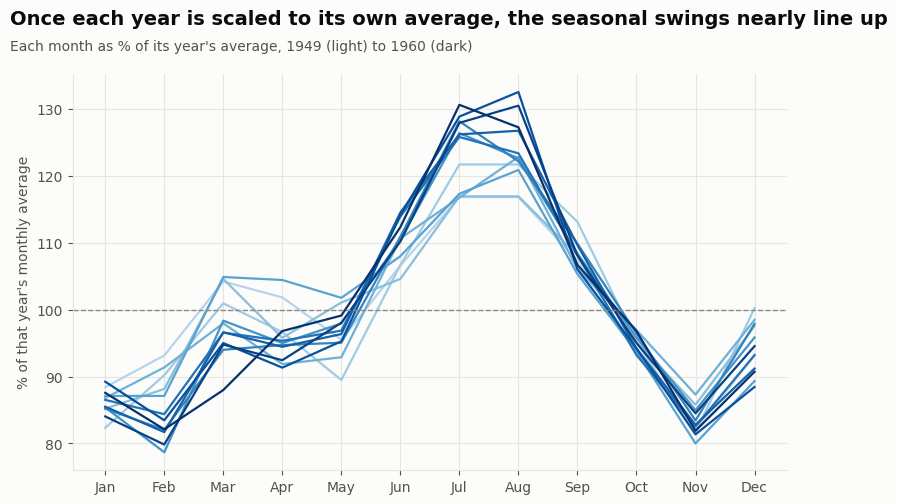

In [9]:
index = wide / wide.mean() * 100

fig, ax = plt.subplots()
for i, y in enumerate(years):
    ax.plot(index.index, index[y], color=cmap(0.3 + 0.7 * i / (len(years) - 1)), linewidth=1.6)
ax.axhline(100, color=INK_MUTED, linestyle="--", linewidth=1)
ax.set_xticks(range(1, 13), [m[:3] for m in MONTHS])
ax.set_ylabel("% of that year's monthly average")

finish(fig, "Once each year is scaled to its own average, the seasonal swings nearly line up",
       "Each month as % of its year's average, 1949 (light) to 1960 (dark)", name="task5_seasonal_index")

**Chart analysis.** Dividing each month by its year's average makes the curves almost coincide, so the swings are mostly proportional to airline size. The peak-to-low ratio still edges up from about 1.4 to 1.6.

Mostly it's just the airline growing. In absolute numbers the gap between the busiest and quietest month
went from 44k to 232k (over 5x), but the average month also grew almost 4x. If I divide each month by its
year's average, the lines almost sit on top of each other — the summer peak is always roughly 15–35% above
average. So the seasonality is mostly *proportional* (multiplicative): bigger airline, bigger swings.

There is a small real increase though: the peak/low ratio goes from about 1.4 in 1949 to about 1.6 in
1960, and the later (darker) lines have a slightly sharper summer peak.

The chart above settles it. Another option would be plotting chart 1 with a log y-axis — if the swings
look the same size every year on a log scale, the seasonality is proportional.